#### Example running SpaFHy with jupyter notebook for Pallas catchment(s)

In [ ]:
import os
from model_driver import parallel_driver
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
from pathlib import Path
from dotenv import load_dotenv
load_dotenv()
io_path = str(Path(os.getenv('PROJECT_FOLDER'))) # PROJECT_FOLDER=.... from .env file

In [ ]:
# example how to run single catchment or multiple catchments in parallel
catchment = 'pallas'
run_multiple = False # run multiple catchments in parallel

if run_multiple: # running multiple catchments as in catchment_no
    catchment_no = np.arange(2,13,1) # catchment_no from 2 to 12
else:
    catchment_no = 2 # running only catchment_no 2 (= lompolonjängänoja)

folder = os.path.join(io_path, catchment) # io repo

outputfile = parallel_driver(catchment, catchment_no, create_ncf=True, create_spinup=False, output=True, folder=folder)

# Reading the .nc results file that was just created
results = xr.open_dataset(outputfile[0])

*** Starting simulation for catchment no.: 2 ***
*** Running 2D model ***
Running timestep:  1
Timestep: 1 , iterations: 9 , conv1: 0.0007930149093340333 , H[max_index]: -0.0095533701792192
Running timestep:  2


/Users/jpnousu/Models/SpaFHy_v2.0/bucketgrid.py:280: RuntimeWarning: invalid value encountered in power
  Psi = -1 / self.alpha_root*(s**(1.0 / m) - 1.0)**(1.0 / n)  # alpha defines the unit (kPa)


Timestep: 2 , iterations: 14 , conv1: 0.0007538627735925729 , H[max_index]: -0.009559549591642735
Running timestep:  3
Timestep: 3 , iterations: 14 , conv1: 0.0007586057541288938 , H[max_index]: -0.009829474118760118
Running timestep:  4
Timestep: 4 , iterations: 18 , conv1: 0.0008794834566288046 , H[max_index]: -0.0098404151098066
Running timestep:  5
Timestep: 5 , iterations: 19 , conv1: 0.0008224932198004353 , H[max_index]: -0.010012951403780335
Running timestep:  6
Timestep: 6 , iterations: 15 , conv1: 0.0009021724612807702 , H[max_index]: -0.010350989358130391
Running timestep:  7
Timestep: 7 , iterations: 18 , conv1: 0.0006428742162825074 , H[max_index]: -0.009289273472916193
Running timestep:  8
Timestep: 8 , iterations: 14 , conv1: 0.0009565999280880533 , H[max_index]: -0.010023883385770205
Running timestep:  9
Timestep: 9 , iterations: 16 , conv1: 0.000886327937621445 , H[max_index]: -0.011308522393562725
Running timestep:  10
Timestep: 10 , iterations: 18 , conv1: 0.000467174

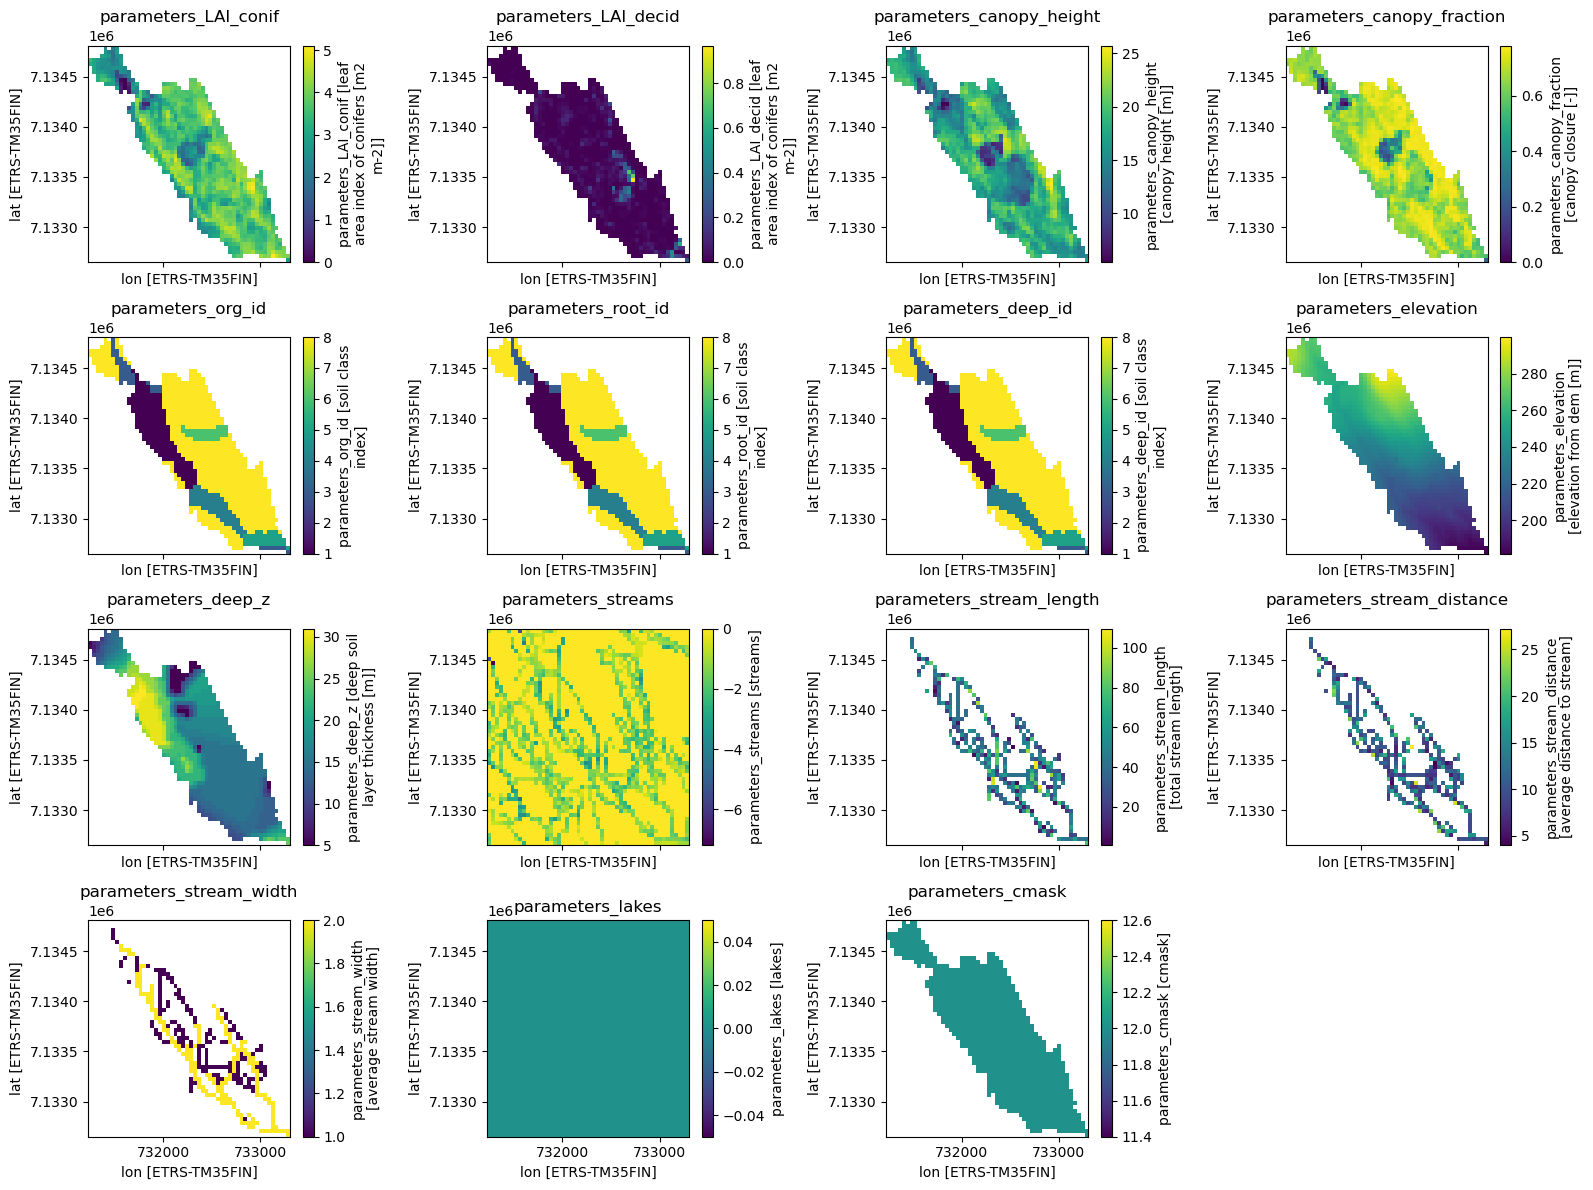

In [2]:
import math

# Collect all keys starting with "parameters_"
param_keys = [k for k in results.keys() if k.startswith("parameters_")]

# Grid setup: 4 columns, rows computed automatically
ncols = 4
nrows = math.ceil(len(param_keys) / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(4*ncols, 3*nrows), sharex=True)

axes = axes.flatten()

for ax, key in zip(axes, param_keys):
    results[key].plot(ax=ax)
    ax.set_title(key)

for ax in axes[len(param_keys):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


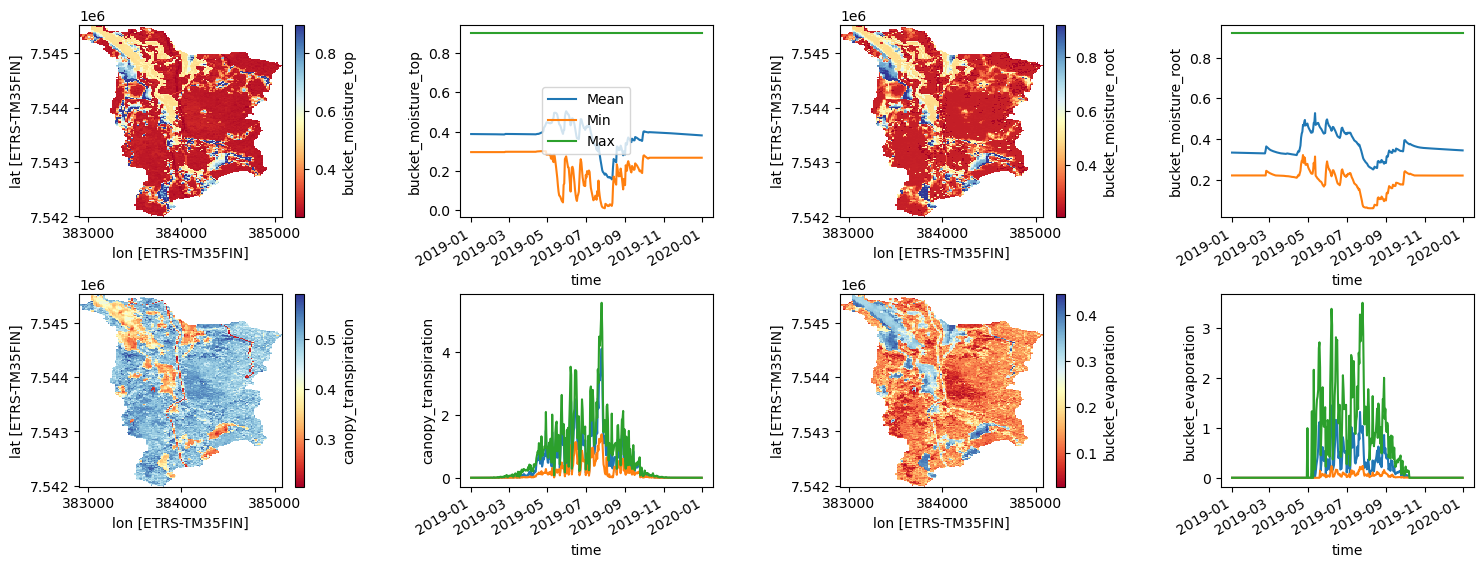

In [3]:
# example plot 1 (works for 1D, TOP, or 2D simulation)
fig, axes = plt.subplots(2, 4, figsize=(18, 6))  # 2 rows, 4 columns
axes = axes.flatten()  # Flatten to easily index 0–7

# Plot 1
results['bucket_moisture_top'].mean(dim='time').plot(ax=axes[0], cmap='RdYlBu')

# Plot 2
results['bucket_moisture_top'].mean(dim=['lat', 'lon']).plot(ax=axes[1], label='Mean')
results['bucket_moisture_top'].min(dim=['lat', 'lon']).plot(ax=axes[1], label='Min')
results['bucket_moisture_top'].max(dim=['lat', 'lon']).plot(ax=axes[1], label='Max')
axes[1].legend()
# Plot 3
results['bucket_moisture_root'].mean(dim='time').plot(ax=axes[2], cmap='RdYlBu')

# Plot 4
results['bucket_moisture_root'].mean(dim=['lat', 'lon']).plot(ax=axes[3], label='Mean')
results['bucket_moisture_root'].min(dim=['lat', 'lon']).plot(ax=axes[3], label='Min')
results['bucket_moisture_root'].max(dim=['lat', 'lon']).plot(ax=axes[3], label='Max')

# Plot 5
results['canopy_transpiration'].mean(dim='time').plot(ax=axes[4], cmap='RdYlBu')

# Plot 6
results['canopy_transpiration'].mean(dim=['lat', 'lon']).plot(ax=axes[5], label='Mean')
results['canopy_transpiration'].min(dim=['lat', 'lon']).plot(ax=axes[5], label='Min')
results['canopy_transpiration'].max(dim=['lat', 'lon']).plot(ax=axes[5], label='Max')

# Plot 7
results['bucket_evaporation'].mean(dim='time').plot(ax=axes[6], cmap='RdYlBu')

# Plot 8
results['bucket_evaporation'].mean(dim=['lat', 'lon']).plot(ax=axes[7], label='Mean')
results['bucket_evaporation'].min(dim=['lat', 'lon']).plot(ax=axes[7], label='Min')
results['bucket_evaporation'].max(dim=['lat', 'lon']).plot(ax=axes[7], label='Max')

# Plot 8
#results['parameters_streams'].plot(ax=axes[7])

plt.subplots_adjust(wspace=0.5, hspace=0.4)  # Adjust spacing between plots

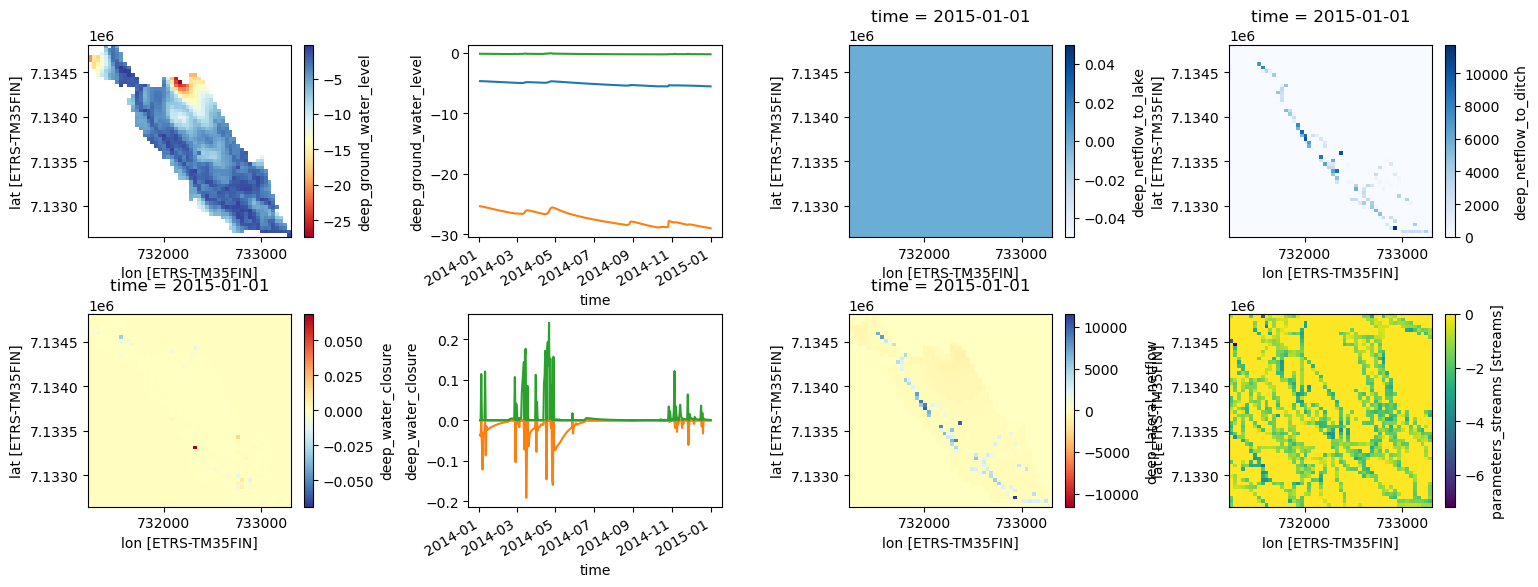

In [4]:
# example plot 2 (works only for 2D simulation)

fig, axes = plt.subplots(2, 4, figsize=(18, 6))  # 2 rows, 4 columns
axes = axes.flatten()  # Flatten to easily index 0–7

# Plot 1
results['deep_ground_water_level'].mean(dim='time').plot(ax=axes[0], cmap='RdYlBu')

# Plot 2
results['deep_ground_water_level'].mean(dim=['lat', 'lon']).plot(ax=axes[1], label='Mean')
results['deep_ground_water_level'].min(dim=['lat', 'lon']).plot(ax=axes[1], label='Min')
results['deep_ground_water_level'].max(dim=['lat', 'lon']).plot(ax=axes[1], label='Max')

# Plot 3
results['deep_netflow_to_lake'].cumsum(dim='time')[-1].plot(ax=axes[2], cmap='Blues')

# Plot 4
#results['deep_netflow_to_ditch'][0].plot(ax=axes[3])
results['deep_netflow_to_ditch'].cumsum(dim='time')[-1].plot(ax=axes[3], cmap='Blues')

# Plot 5
#results['deep_water_closure'][-1].plot(ax=axes[4])
results['deep_water_closure'].cumsum(dim='time')[-1].plot(ax=axes[4], cmap='RdYlBu_r')

# Plot 6
results['deep_water_closure'].mean(dim=['lat', 'lon']).plot(ax=axes[5], label='Mean')
results['deep_water_closure'].min(dim=['lat', 'lon']).plot(ax=axes[5], label='Min')
results['deep_water_closure'].max(dim=['lat', 'lon']).plot(ax=axes[5], label='Max')

# Plot 7
#results['deep_lateral_netflow'].min(dim='time').plot(ax=axes[6])
results['deep_lateral_netflow'].cumsum(dim='time')[-1].plot(ax=axes[6], cmap='RdYlBu')

# Plot 8
results['parameters_streams'].plot(ax=axes[7])

plt.subplots_adjust(wspace=0.5, hspace=0.4)  # Adjust spacing between plots

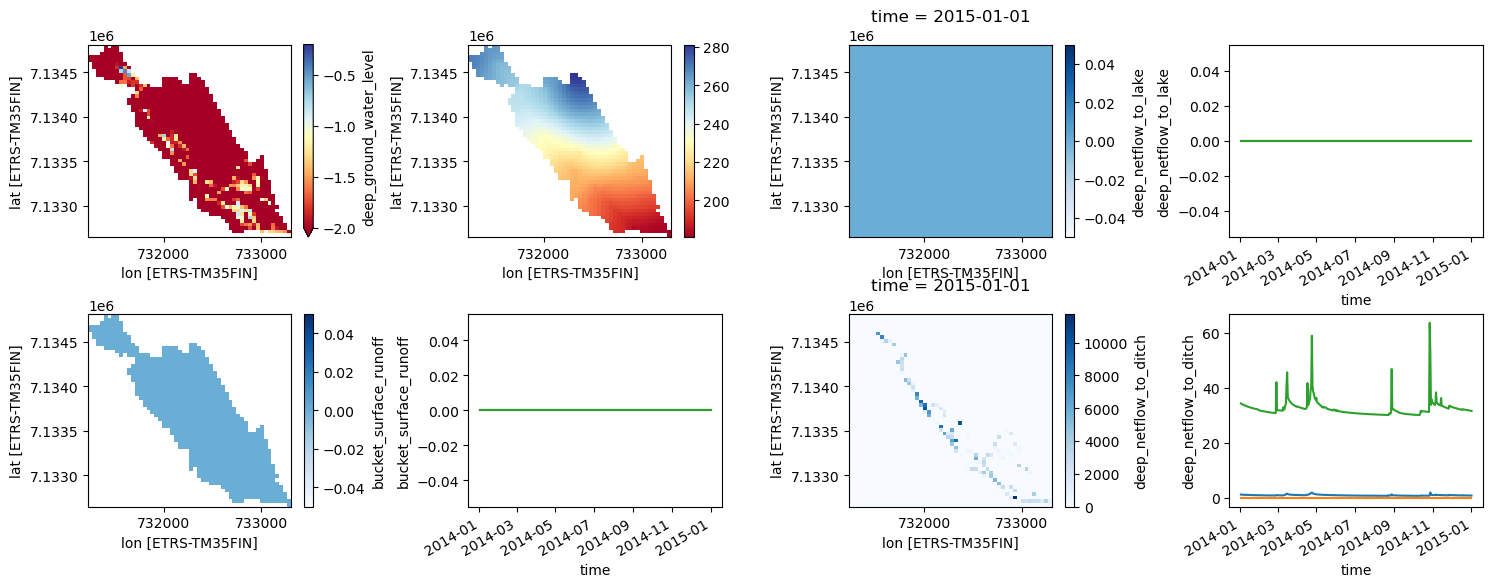

In [5]:
# example plot 2 (works only for 2D simulation)

fig, axes = plt.subplots(2, 4, figsize=(18, 6))  # 2 rows, 4 columns
axes = axes.flatten()  # Flatten to easily index 0–7

# Plot 1
results['deep_ground_water_level'].mean(dim='time').plot(ax=axes[0], vmin=-2., cmap='RdYlBu')

# Plot 2
(results['parameters_elevation'] + results['deep_ground_water_level'].mean(dim='time')).plot(ax=axes[1], cmap='RdYlBu')


# Plot 3
results['deep_netflow_to_lake'].cumsum(dim='time')[-1].plot(ax=axes[2], cmap='Blues')

# Plot 4
#results['deep_netflow_to_ditch'][0].plot(ax=axes[3])
results['deep_netflow_to_lake'].mean(dim=['lat', 'lon']).plot(ax=axes[3], label='Mean')
results['deep_netflow_to_lake'].min(dim=['lat', 'lon']).plot(ax=axes[3], label='Min')
results['deep_netflow_to_lake'].max(dim=['lat', 'lon']).plot(ax=axes[3], label='Max')

# Plot 5
#results['deep_water_closure'][-1].plot(ax=axes[4])
results['bucket_surface_runoff'].mean(dim='time').plot(ax=axes[4], cmap='Blues')

# Plot 6
results['bucket_surface_runoff'].mean(dim=['lat', 'lon']).plot(ax=axes[5], label='Mean')
results['bucket_surface_runoff'].min(dim=['lat', 'lon']).plot(ax=axes[5], label='Min')
results['bucket_surface_runoff'].max(dim=['lat', 'lon']).plot(ax=axes[5], label='Max')

# Plot 7
#results['deep_lateral_netflow'].min(dim='time').plot(ax=axes[6])
results['deep_netflow_to_ditch'].cumsum(dim='time')[-1].plot(ax=axes[6], cmap='Blues')

# Plot 8
results['deep_netflow_to_ditch'].mean(dim=['lat', 'lon']).plot(ax=axes[7], label='Mean')
results['deep_netflow_to_ditch'].min(dim=['lat', 'lon']).plot(ax=axes[7], label='Min')
results['deep_netflow_to_ditch'].max(dim=['lat', 'lon']).plot(ax=axes[7], label='Max')

plt.subplots_adjust(wspace=0.5, hspace=0.4)  # Adjust spacing between plots

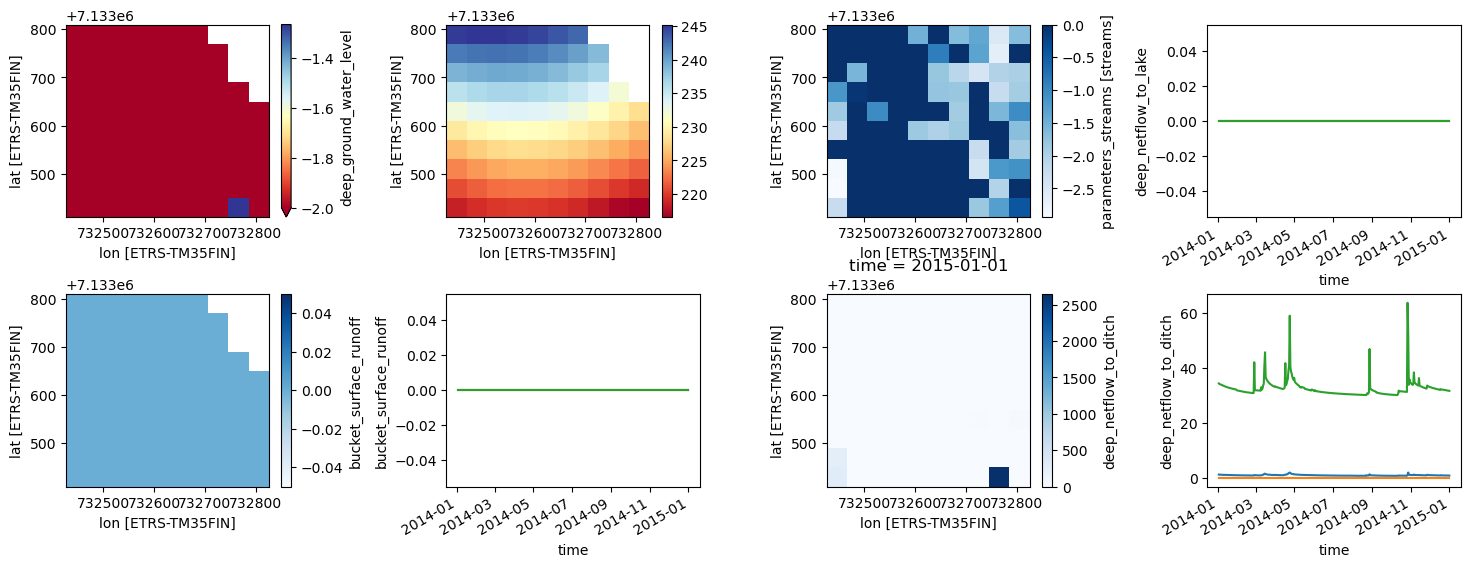

In [6]:
# example plot 2 (works only for 2D simulation)

row_slice = slice(25, 35)
col_slice = slice(30, 40)

fig, axes = plt.subplots(2, 4, figsize=(18, 6))  # 2 rows, 4 columns
axes = axes.flatten()  # Flatten to easily index 0–7

# Plot 1
results['deep_ground_water_level'].mean(dim='time')[row_slice,col_slice].plot(ax=axes[0], vmin=-2., cmap='RdYlBu')

# Plot 2
(results['parameters_elevation'][row_slice, col_slice] + results['deep_ground_water_level'].mean(dim='time')[row_slice, col_slice]).plot(ax=axes[1], cmap='RdYlBu')


# Plot 3
results['parameters_streams'][row_slice, col_slice].plot(ax=axes[2], cmap='Blues')

# Plot 4
#results['deep_netflow_to_ditch'][0].plot(ax=axes[3])
results['deep_netflow_to_lake'].mean(dim=['lat', 'lon']).plot(ax=axes[3], label='Mean')
results['deep_netflow_to_lake'].min(dim=['lat', 'lon']).plot(ax=axes[3], label='Min')
results['deep_netflow_to_lake'].max(dim=['lat', 'lon']).plot(ax=axes[3], label='Max')

# Plot 5
#results['deep_water_closure'][-1].plot(ax=axes[4])
results['bucket_surface_runoff'].mean(dim='time')[row_slice,col_slice].plot(ax=axes[4], cmap='Blues')

# Plot 6
results['bucket_surface_runoff'].mean(dim=['lat', 'lon']).plot(ax=axes[5], label='Mean')
results['bucket_surface_runoff'].min(dim=['lat', 'lon']).plot(ax=axes[5], label='Min')
results['bucket_surface_runoff'].max(dim=['lat', 'lon']).plot(ax=axes[5], label='Max')

# Plot 7
#results['deep_lateral_netflow'].min(dim='time').plot(ax=axes[6])
results['deep_netflow_to_ditch'].cumsum(dim='time')[-1,row_slice, col_slice].plot(ax=axes[6], cmap='Blues')

# Plot 8
results['deep_netflow_to_ditch'].mean(dim=['lat', 'lon']).plot(ax=axes[7], label='Mean')
results['deep_netflow_to_ditch'].min(dim=['lat', 'lon']).plot(ax=axes[7], label='Min')
results['deep_netflow_to_ditch'].max(dim=['lat', 'lon']).plot(ax=axes[7], label='Max')

plt.subplots_adjust(wspace=0.5, hspace=0.4)  # Adjust spacing between plots

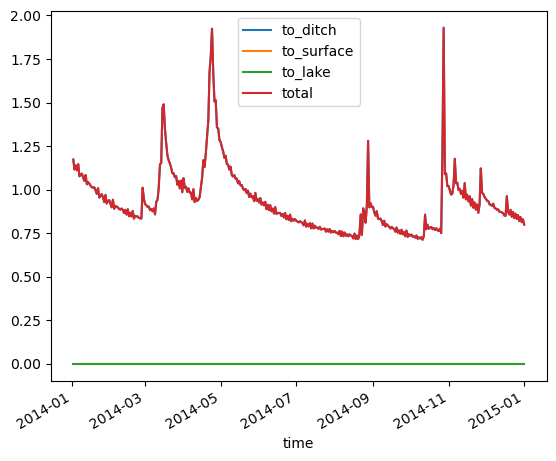

In [7]:
results['deep_netflow_to_ditch'].mean(dim=['lat','lon']).plot(label='to_ditch')
results['bucket_surface_runoff'].mean(dim=['lat','lon']).plot(label='to_surface')
results['deep_netflow_to_lake'].mean(dim=['lat','lon']).plot(label='to_lake')
(results['deep_netflow_to_ditch'].mean(dim=['lat','lon']) + 
 results['bucket_surface_runoff'].mean(dim=['lat','lon']) + 
 results['deep_netflow_to_lake'].mean(dim=['lat','lon'])).plot(label='total')
plt.legend()